# NB04 — ML Models for CAR Sign Prediction

**Question:** Does the LLM-augmented feature set predict the sign of post-call CAR (`car_2_11`, the 10-day window) above chance?

## Pipeline

```
NB00 raw transcripts/prices ──▶ NB01 EDA ──▶ NB02 RAG + GPT-4o → llm_signals.parquet
                                                          │
NB04 (this notebook):  sessions + prices + llm_signals ───┤
   1. EDA                — distributions, missing rates, single-feature ICs, corr
   2. Feature build      — pre-event technicals + sector dummies + LLM scores
   3. Clean              — dropna, train-only winsorize, |CAR|>0.5σₑ√10 tail filter
   4. Model loop         — TimeSeriesSplit(5) CV over logreg / svm / rf / xgb
   5. Tune winner        — Optuna TPE, 50 trials
   6. Save               — refit on train+val, pickle for NB05 backtest
```

## Ablation arms

| Arm | Features | Purpose |
|-----|----------|---------|
| **A** | intercept only (base rate) | BuyHold floor |
| **B** | tech (5) + sector one-hot | isolates LLM alpha when compared to C |
| **C** | tech + sector + LLM (6) | full feature set — main candidate |

NB05 backtests **B vs C** to attribute alpha specifically to the LLM signal.

## Tech indicators (computed strictly from prices with `date < event_date`)

| Feature | Formula | Meaning |
|---------|---------|---------|
| `rsi_7` | `100 − 100/(1+RS)`, `RS = avg_gain₇/avg_loss₇` | 7-day Relative Strength; >70 overbought, <30 oversold |
| `macd_hist` | `MACD₁₂,₂₆ − Signal₉` | momentum vs trend; sign flip = regime change |
| `mom_5d` | `Pₜ₋₁/Pₜ₋₆ − 1` | 5-day price drift heading into the call |
| `vol_10d` | `std(rₜ₋₁₀:ₜ₋₁) · √252` | annualized realized vol — risk regime proxy |
| `log_dollar_vol` | `log(mean(P·V) over t−30:t−10)` | liquidity proxy (skips the pre-call run-up window) |

Sector dummies use `config.SECTOR_LIST` to control for industry base rates.

In [11]:
import sys, warnings, joblib
from pathlib import Path
from typing import Literal, Callable, Dict, Tuple
warnings.filterwarnings('ignore')

sys.path.insert(0, str(Path.cwd().parent))
sys.path.insert(0, str(Path.cwd().parent / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ta.momentum import RSIIndicator
from ta.trend import MACD

from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import config
from llm_agent.data_loader import load_sessions, load_prices, load_llm_signals, split_by_period

sns.set_style('whitegrid')
MAIN_WINDOW = 'car_2_11'

In [2]:
# ── feature builder ───────────────────
# Per-event feature matrix for the three ablation arms (A/B/C).
# All technicals use prices STRICTLY BEFORE event_date — no look-ahead.

LLM_FEATURES = ['sentiment_num', 'confidence', 'certainty',
                'evasion', 'guidance_num', 'tone_num']
TECH_FEATURES = ['rsi_7', 'macd_hist', 'mom_5d', 'vol_10d', 'log_dollar_vol']


def _technicals_at_event(price_t: pd.DataFrame, event_date) -> dict | None:
    """
    Compute technical features at the event date. 
    Returns None if not enough data or any feature is non-finite.
    """
    sub = price_t[price_t.date < pd.to_datetime(event_date)].sort_values('date')
    if len(sub) < 35:
        return None
    
    close = sub['adj_close'].astype(float).reset_index(drop=True)
    vol = sub['volume'].astype(float).reset_index(drop=True)
    ret = close.pct_change()
    
    try:
        rsi_7 = float(RSIIndicator(close, window=7).rsi().iloc[-1])
        macd_hist = float(MACD(close).macd_diff().iloc[-1])
    except Exception:
        return None
    
    if not np.isfinite(rsi_7) or not np.isfinite(macd_hist):
        return None
    
    mom_5d = float(close.iloc[-1] / close.iloc[-6] - 1) if len(close) >= 6 else None
    vol_10d = float(ret.iloc[-10:].std() * np.sqrt(252)) if len(ret) >= 11 else None
    dollar_vol = (close * vol).iloc[-30:-10]
    log_dollar_vol = float(np.log(dollar_vol.mean())) if (dollar_vol > 0).all() else None
    
    return {'rsi_7': rsi_7, 'macd_hist': macd_hist, 'mom_5d': mom_5d,
            'vol_10d': vol_10d, 'log_dollar_vol': log_dollar_vol}


def build_technicals(sessions: pd.DataFrame, prices: pd.DataFrame) -> pd.DataFrame:
    sessions = sessions.drop_duplicates(
        subset=['ticker', 'fiscal_year', 'fiscal_quarter'], keep='first').copy()
    sessions['event_date'] = pd.to_datetime(sessions['mostimportantdate'])
    cache = {t: prices[prices.ticker == t] for t in sessions.ticker.unique()}
    rows = []
    for r in sessions.itertuples(index=False):
        feats = _technicals_at_event(cache[r.ticker], r.event_date) or {k: None for k in TECH_FEATURES}
        rows.append({'session_id': f'{r.ticker}_{r.fiscal_year}_Q{r.fiscal_quarter}', **feats})
    return pd.DataFrame(rows)


def _sector_dummies(tickers: pd.Series) -> pd.DataFrame:
    sec = tickers.map(config.SECTOR_MAP)
    dummies = pd.get_dummies(sec, prefix='sec').reindex(
        columns=[f'sec_{s}' for s in config.SECTOR_LIST], fill_value=0)
    return dummies.astype(int)


def build_feature_matrix(sessions, prices, llm_signals, arm: Literal['A', 'B', 'C']):
    base = sessions.drop_duplicates(
        subset=['ticker', 'fiscal_year', 'fiscal_quarter'], keep='first').copy()
    base['event_date'] = pd.to_datetime(base['mostimportantdate'])
    base['session_id'] = (base.ticker + '_' + base.fiscal_year.astype(str)
                          + '_Q' + base.fiscal_quarter.astype(str))
    base = base[['session_id', 'ticker', 'fiscal_year', 'fiscal_quarter', 'event_date']]
    if arm == 'A':
        base['intercept'] = 1.0
        return base
    tech = build_technicals(sessions, prices)
    out = base.merge(tech, on='session_id', how='left')
    sec = _sector_dummies(out['ticker'])
    out = pd.concat([out.reset_index(drop=True), sec.reset_index(drop=True)], axis=1)
    if arm == 'B':
        return out
    if llm_signals is None:
        raise ValueError("arm='C' requires llm_signals")
    return out.merge(llm_signals[['session_id', *LLM_FEATURES]], on='session_id', how='left')


def feature_columns(arm: Literal['A', 'B', 'C']) -> list[str]:
    if arm == 'A':
        return ['intercept']
    sector_cols = [f'sec_{s}' for s in config.SECTOR_LIST]
    base = TECH_FEATURES + sector_cols
    return base if arm == 'B' else base + LLM_FEATURES

---
## § 1. EDA — feature matrix

In [ ]:
sessions = load_sessions()
prices = load_prices()
llm = load_llm_signals()
car = pd.read_parquet(config.CLEAN_DIR / 'car_labels.parquet')

# 'C' means using all features for target construction; will ablate later in modeling
X_full = build_feature_matrix(sessions, prices, llm, 'C') 

df = X_full.merge(car[['session_id', MAIN_WINDOW, 'sigma_e']], on='session_id', how='inner')
df['y'] = (df[MAIN_WINDOW] > 0).astype(int)
print(f'rows: {len(df)},  unique tickers: {df.ticker.nunique()}')

rows: 1496,  unique tickers: 50


In [4]:
# Missing rate per feature
all_cols = feature_columns('C')
miss = df[all_cols].isna().mean().sort_values(ascending=False)
print('Missing rate (top 10):')
print(miss.head(10).round(4))

Missing rate (top 10):
rsi_7               0.0
macd_hist           0.0
mom_5d              0.0
vol_10d             0.0
log_dollar_vol      0.0
sec_CommServices    0.0
sec_ConsDisc        0.0
sec_ConsStaples     0.0
sec_Energy          0.0
sec_Financials      0.0
dtype: float64


In [5]:
# Class balance per split
for s in ['train','val','test_2024','test_2025']:
    d = split_by_period(df, s)
    print(f'  {s:<10}  n={len(d):<5}  y=1 rate={d.y.mean():.3f}')

  train       n=941    y=1 rate=0.499
  val         n=192    y=1 rate=0.526
  test_2024   n=198    y=1 rate=0.530
  test_2025   n=165    y=1 rate=0.539


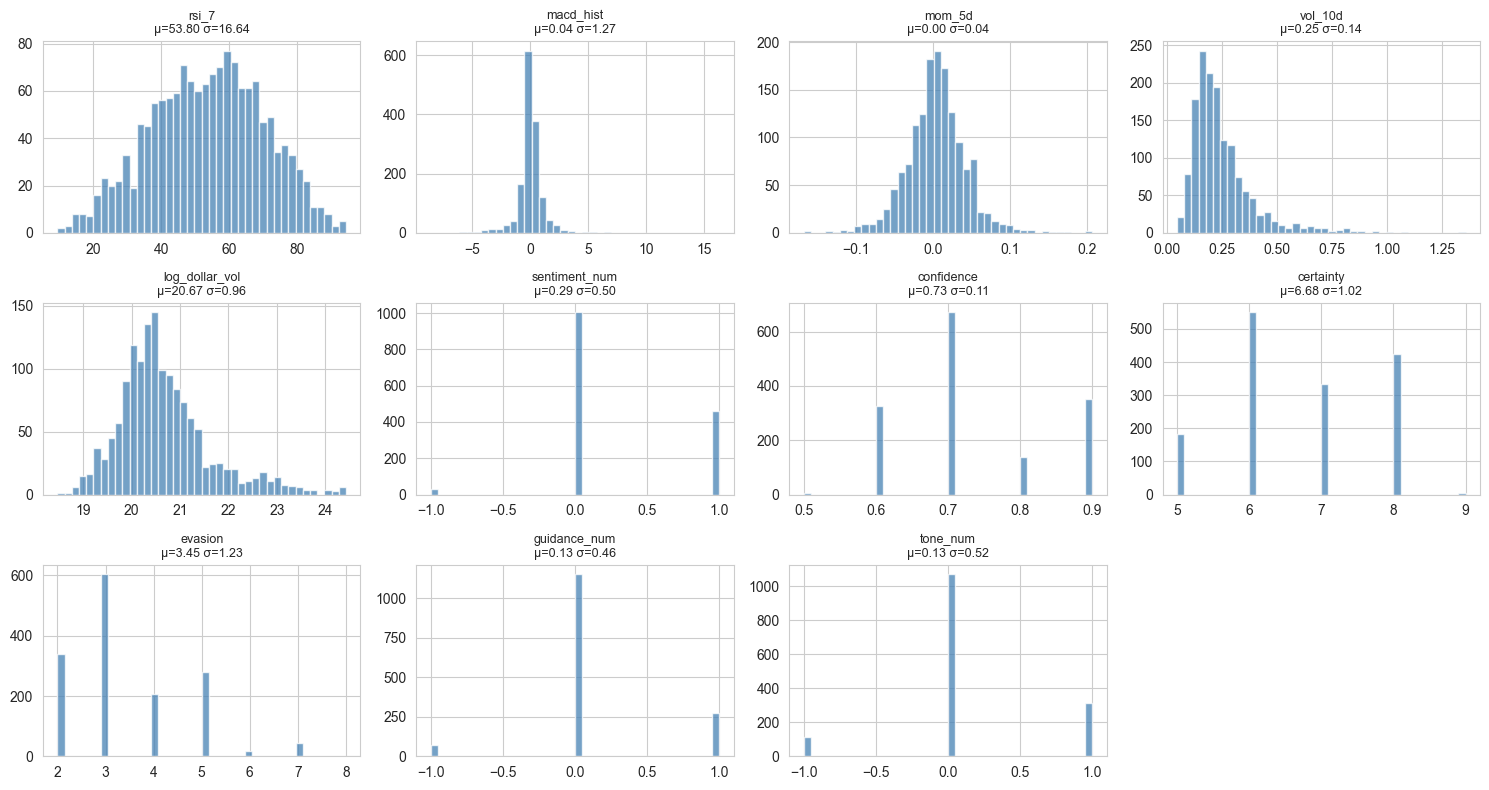

In [6]:
# Numeric feature distributions (tech + LLM)
num_feats = TECH_FEATURES + LLM_FEATURES
fig, axes = plt.subplots(3, 4, figsize=(15, 8))
for ax, c in zip(axes.flat, num_feats):
    s = df[c].dropna()
    ax.hist(s, bins=40, color='steelblue', alpha=0.75)
    ax.set_title(f'{c}\nμ={s.mean():.2f} σ={s.std():.2f}', fontsize=9)
for ax in axes.flat[len(num_feats):]:
    ax.axis('off')
plt.tight_layout(); plt.show()

**Feature distributions.** The top-row technicals look as expected: `rsi_7` is roughly normal around 50 (μ=53.8), slightly long-biased but not crowded; `macd_hist` / `mom_5d` are symmetric around 0 with fat tails driven by pre/post-earnings moves; `vol_10d` and `log_dollar_vol` are right-skewed, consistent with the lognormal nature of realized vol and dollar volume.

The six LLM signals in the lower rows show a **discrete, stair-step shape** — a direct consequence of the GPT-4o prompt constraining outputs to fixed value sets (e.g. sentiment ∈ {−1,0,1}, confidence ∈ {0.5,…,0.9}, certainty/evasion ∈ integers 1–9). Note that the three-valued variables `sentiment_num`, `guidance_num`, and `tone_num` are all clearly **right-skewed** (0/positive dominate, negatives are rare), reflecting the systematic optimism bias of management on earnings calls; `evasion` clusters at 3–4, meaning most Q&A responses are moderately evasive. 

This discreteness implies linear models can essentially only learn step responses around thresholds — tree-based models are a better fit for capturing it.

In [ ]:
# Single-feature IC: split each numeric feature at its median, look at y mean diff
ic_rows = []
for c in num_feats:
    s = df[[c, 'y']].dropna()
    if s[c].nunique() < 3:
        med = s[c].median() # if only 2 unique values, median is the lower one, so >med means the higher value
        hi = s[s[c] >  med]['y'].mean()
        lo = s[s[c] <= med]['y'].mean()
    else:
        med = s[c].median()
        hi = s[s[c] >  med]['y'].mean()
        lo = s[s[c] <= med]['y'].mean()
    ic_rows.append({'feature': c, 'y|hi': hi, 'y|lo': lo, 'diff': hi - lo})
ic = pd.DataFrame(ic_rows).sort_values('diff', key=abs, ascending=False)
print('Single-feature IC (median split, y=P[CAR>0]):')
print(ic.round(3).to_string(index=False))

Single-feature IC (median split, y=P[CAR>0]):
       feature  y|hi  y|lo   diff
         rsi_7 0.480 0.543 -0.063
       evasion 0.541 0.494  0.047
      tone_num 0.494 0.516 -0.022
 sentiment_num 0.497 0.518 -0.021
        mom_5d 0.501 0.521 -0.020
       vol_10d 0.516 0.507  0.009
     certainty 0.506 0.514 -0.008
  guidance_num 0.506 0.513 -0.007
    confidence 0.507 0.513 -0.006
     macd_hist 0.511 0.512 -0.001
log_dollar_vol 0.511 0.512 -0.001


**Single-feature IC (median split).** For each numeric feature we split the sample at the median and report `P(CAR>0)` on each side; `diff` is the upper-half minus lower-half hit rate — a crude univariate IC.

The picture is sobering: **no single feature carries meaningful directional power**. The strongest signal is `rsi_7` at −6.3pp (high RSI → *lower* hit rate, i.e. mild mean-reversion after overbought runs), followed by `evasion` at +4.7pp (more evasive Q&A tones associate with *positive* CAR — counterintuitive, possibly a "management hides good news to manage expectations" effect, or just noise at this sample size). Everything else sits within ±2pp of zero, well inside sampling error for n≈1,500.

**Implication for modelling.** Since no feature is individually informative, any predictive lift must come from **interactions and joint structure** across tech + LLM dimensions — which is exactly what the tree ensembles (RF / XGB) in §3 are designed to exploit. It also sets a realistic ceiling

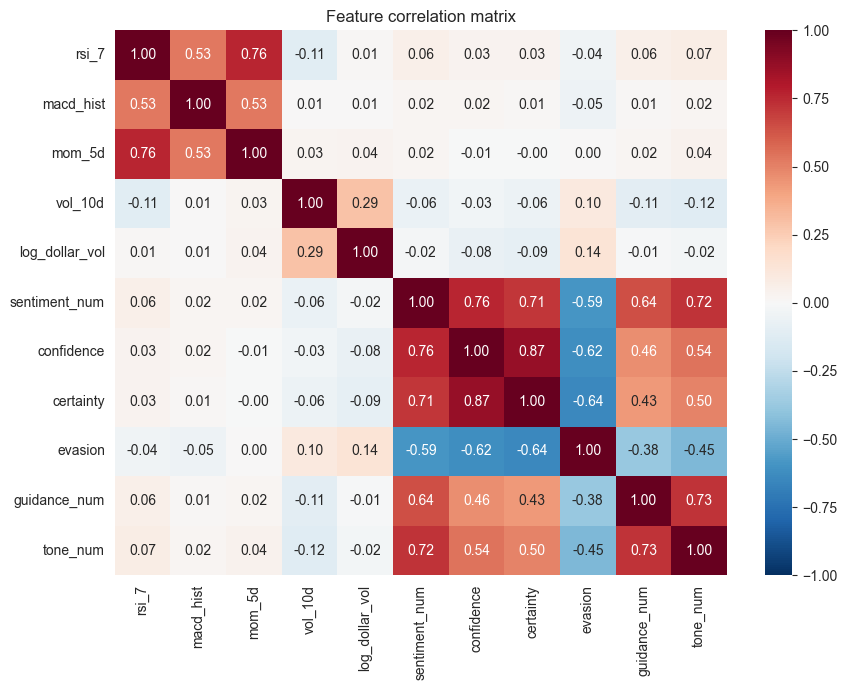

|corr| > 0.9 pairs: none


In [8]:
# Correlation matrix (numeric features only)
corr = df[num_feats].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, center=0, ax=ax)
ax.set_title('Feature correlation matrix')
plt.tight_layout(); plt.show()

# Flag |corr| > 0.9 pairs
pairs = []
for i, a in enumerate(num_feats):
    for b in num_feats[i+1:]:
        c = corr.loc[a, b]
        if abs(c) > 0.9:
            pairs.append((a, b, c))
print('|corr| > 0.9 pairs:', pairs if pairs else 'none')

**Feature correlation matrix.** The matrix shows a clean **block-diagonal structure** — the tech block (top-left 5×5) and the LLM block (bottom-right 6×6) are nearly orthogonal (|cross-block corr| ≤ 0.14), meaning the two feature families capture entirely different information dimensions. **This is exactly the structural prerequisite for arm C to add value over arm B.**

**Within-block observations:**
- **Tech block**: `rsi_7 ↔ mom_5d` = 0.76, `rsi_7 ↔ macd_hist` = 0.53, `macd_hist ↔ mom_5d` = 0.53 — the three momentum-flavored indicators are highly collinear (all measuring the same thing: recent price trend). `vol_10d ↔ log_dollar_vol` = 0.29 is a mild vol/liquidity link. No pair exceeds |corr|>0.9, so no drops are needed, but tree-model feature importance will be diluted across the three momentum variables.
- **LLM block**: `confidence ↔ certainty` = 0.87 is near the redundancy threshold; `sentiment_num` correlates 0.64–0.76 with confidence/certainty/tone/guidance, forming a coherent "optimistic–confident–assertive–positive-guidance" tone cluster. `evasion` is significantly negative against the other five (−0.38 to −0.64), directionally sensible (more candor → more positive tone) but implying its standalone information is limited.

**Modelling implications.** The LLM block has elevated within-cluster redundancy (especially the confidence/certainty pair), which will destabilize linear-model coefficients; tree models are more robust, but per-feature importances should be read carefully — an "important" LLM feature may just be acting as a proxy for the whole tone cluster. The cross-block orthogonality, however, guarantees that the tech and LLM contributions can be cleanly separated by the §3 ablation (B vs C).

---
## § 2. Feature engineering / cleaning

1. Drop rows with any NA in features / target / σₑ.
2. Winsorize tech features at 1% / 99% (train-only bounds).
3. **Tail filter for training**: drop events with `|CAR| < 0.5·σₑ·√10` from the training/val sets — these middle 40% are noise that obscures the signal. Inference (test peek + NB05 backtest) still runs on **all** events; only the fit set is filtered.
4. Freeze the final column list `cols`.

**Tail filter** 

I'll use tail filter to drop the noisy middle, keep only events with real signal.

For each event compute the threshold

$$
\text{car\_thr} \;=\; 0.5 \cdot \sigma_e \cdot \sqrt{10}
$$

where `σₑ` is the residual volatility from the market-model regression (NB02) and √10 scales it to the 10-day CAR window. An event is flagged `is_tail = |CAR| > car_thr` — i.e. the realized abnormal return exceeds **half a standard deviation** of what the noise model alone would produce over 10 days.

**Why filter?** Roughly the middle 40% of events have |CAR| inside the σₑ·√10 noise band. For these, the binary label `y = (CAR > 0)` is essentially a coin flip — the sign is driven by random walk, not by anything the call transcript or pre-event technicals could plausibly explain. Feeding them to the classifier only dilutes the signal-to-noise ratio and pulls the decision boundary toward the prior. By keeping only the **tails** (|CAR| meaningfully above noise), we let the model learn from events where the label actually carries information.

**How it's used:**
- **Fit / validation** (`Xtr, ytr, Xv, yv`): tail-only — 1480 → 863 rows (58.3%). Model fitting and Optuna CV scoring all happen on this filtered set.
- **Inference** (NB05 backtest): the saved model scores **all** 1480 events. Filtering at deploy time would induce a look-ahead selection bias (you don't know |CAR| until after the holding period). The trade-off — train where labels are clean, predict everywhere — is standard for event-study classifiers.

In [9]:
before = len(df)
df = df.dropna(subset=all_cols + ['y', 'sigma_e']).sort_values('event_date').reset_index(drop=True)
print(f'dropna: {before} → {len(df)}  ({before - len(df)} rows lost)')

# Winsorize tech features at 1%/99% — bounds learned from TRAIN ONLY to avoid leakage
train_mask = df['fiscal_year'].isin(config.TRAIN_YEARS)
for c in TECH_FEATURES:
    lo, hi = df.loc[train_mask, c].quantile([0.01, 0.99])
    df[c] = df[c].clip(lo, hi)
print('winsorized tech features at train [1%, 99%]')

# Tail filter: keep only events where |CAR| > 0.5·σₑ·√10 for fitting
WINDOW_DAYS = 10
df['car_thr'] = 0.5 * df['sigma_e'] * np.sqrt(WINDOW_DAYS)
df['is_tail'] = df[MAIN_WINDOW].abs() > df['car_thr']
n_tail = int(df['is_tail'].sum())
print(f'tail filter: |CAR| > 0.5σₑ·√10  →  {n_tail}/{len(df)} kept ({n_tail/len(df)*100:.1f}%)')

cols = all_cols
print(f'final feature count: {len(cols)}')

dropna: 1496 → 1480  (16 rows lost)
winsorized tech features at train [1%, 99%]
tail filter: |CAR| > 0.5σₑ·√10  →  863/1480 kept (58.3%)
final feature count: 22


In [10]:
splits = {s: split_by_period(df, s) for s in ['train','val','test_2024','test_2025']}
print('Full-sample splits (used for inference / NB05 backtest):')
for s, d in splits.items():
    print(f'  {s:<10}  n={len(d):<5}  y=1 rate={d.y.mean():.3f}')

# Tail-only sets feed model fitting (training/val).
splits_tail = {s: d[d['is_tail']].copy() for s, d in splits.items()}
print('\nTail-filtered splits (used for fit + val AUC):')
for s, d in splits_tail.items():
    print(f'  {s:<10}  n={len(d):<5}  y=1 rate={d.y.mean() if len(d)>0 else float("nan"):.3f}')

Xtr, ytr = splits_tail['train'][cols].values, splits_tail['train']['y'].values
Xv,  yv  = splits_tail['val'][cols].values,   splits_tail['val']['y'].values

Full-sample splits (used for inference / NB05 backtest):
  train       n=925    y=1 rate=0.508
  val         n=192    y=1 rate=0.526
  test_2024   n=198    y=1 rate=0.530
  test_2025   n=165    y=1 rate=0.539

Tail-filtered splits (used for fit + val AUC):
  train       n=537    y=1 rate=0.507
  val         n=108    y=1 rate=0.500
  test_2024   n=120    y=1 rate=0.533
  test_2025   n=98     y=1 rate=0.449


**EDA & cleaning — sanity check.**

- **Clean data**: 1,496 events × 50 tickers, 0% missing across 22 features, no |corr|>0.9 pairs, dropna loses only 16 rows.
- **Balanced classes**: y=1 rate sits at 0.50–0.54 across all four splits — no resampling needed.
- **No univariate signal**: best single-feature IC is just 6.3pp (rsi_7), rest <2pp → predictive lift must come from interactions, favouring tree models.
- **Tail filter**: keeps 863/1480 (58%), shrinking training to 537 rows — small-sample regime, so we lean on TimeSeriesSplit(5) + Optuna to control overfitting.
- **Test_2025 tail y=1 rate only 49%**: the volatile regime carries more downside tails — a useful stress test for NB05.

---
## § 3. Modelling — `train_eval` wrapper

`train_eval(name, X_train, y_train, X_val, y_val, n_splits=5)` does:
1. `GridSearchCV(scoring='roc_auc', cv=TimeSeriesSplit(5))` on train
2. Refits the winner on full train
3. Returns `{'model', 'cv_auc_mean', 'cv_auc_std', 'cv_auc_folds', 'best_params', 'val_metrics'}`

We loop over **logreg / svm / rf / xgb** and compare.

**Model choice — why these four.**

We benchmark **logreg / svm / rf / xgb** because together they span the bias–variance spectrum on a small (n=537), mixed-feature (continuous tech + discrete LLM + sparse sector dummies), low-SNR event-study problem:

- **LogReg** — linear baseline. Cheap, interpretable, and the right reference point: if non-linear models can't beat it, the LLM features aren't carrying joint structure worth modelling.
- **SVM (RBF)** — captures smooth non-linear boundaries that linear models miss, and the kernel margin is robust in small samples. A good middle ground between logreg and tree ensembles.
- **Random Forest** — handles the **stair-step LLM features** natively (no scaling, no monotonicity assumption), tolerates the collinear momentum block (rsi/macd/mom_5d) without coefficient blow-up, and — critically — preserves **probability spread**, which downstream NB05 needs for quintile-based long-short gating.
- **XGBoost** — gradient-boosted trees give the strongest in-sample fit and tunable regularization (`reg_lambda`, `min_child_weight`, subsampling), making it the natural candidate to push CV AUC if the signal exists.

**What we deliberately skipped**: deep nets (n=537 is too small), naive Bayes (feature independence is violated by the LLM tone cluster), kNN (curse of dimensionality with 22 features and a noisy label). The four chosen models cover linear / kernel / bagging / boosting — if none of them lift AUC meaningfully above 0.5, the conclusion is about the signal, not the model class.

In [ ]:
# ── model wrappers ────────────────────────
# All classifiers wrapped in a StandardScaler→clf Pipeline (uniform interface).
# Tree models don't strictly need scaling, but it keeps the training loop simple.

def _pipe(est) -> Pipeline:
    return Pipeline([('scaler', StandardScaler()), ('clf', est)])


def make_model_grid() -> Dict[str, Tuple[Callable[[], Pipeline], dict]]:
    """name -> (pipeline factory, GridSearchCV param grid keyed on 'clf__*')."""
    return {
        'baseline': (
            lambda: Pipeline([('clf', DummyClassifier(strategy='prior'))]),
            {},
        ),
        'logreg': (
            lambda: _pipe(LogisticRegression(max_iter=2000, solver='liblinear')),
            {'clf__C': [0.1, 1.0, 10.0], 'clf__penalty': ['l2']},
        ),
        'svm': (
            lambda: _pipe(SVC(probability=True)),
            {'clf__kernel': ['linear', 'rbf'],
             'clf__C': [0.1, 1.0, 10.0],
             'clf__gamma': ['scale', 0.1]},
        ),
        'rf': (
            lambda: _pipe(RandomForestClassifier(n_estimators=300, random_state=0, n_jobs=-1)),
            {'clf__max_depth': [3, 6, None], 'clf__min_samples_leaf': [1, 5]},
        ),
        'xgb': (
            lambda: _pipe(XGBClassifier(
                n_estimators=300, learning_rate=0.05, eval_metric='logloss',
                random_state=0, n_jobs=-1, verbosity=0,
            )),
            {'clf__max_depth': [3, 5], 'clf__subsample': [0.7, 1.0]},
        ),
    }


def predict_proba_safe(model: Pipeline, X) -> np.ndarray:
    """Positive-class probability; falls back to decision_function for non-prob models."""
    if hasattr(model.named_steps['clf'], 'predict_proba'):
        return model.predict_proba(X)[:, 1]
    return model.decision_function(X)


def eval_metrics(y_true: np.ndarray, p_pred: np.ndarray) -> dict:
    """Binary metrics: AUC, accuracy, F1, plus precision @ top decile."""
    y_pred = (p_pred >= 0.5).astype(int)
    out = {
        'auc': float(roc_auc_score(y_true, p_pred)) if len(np.unique(y_true)) > 1 else float('nan'),
        'acc': float(accuracy_score(y_true, y_pred)),
        'f1':  float(f1_score(y_true, y_pred, zero_division=0)),
    }
    k = max(1, int(0.1 * len(p_pred))) # top 10% cutoff, at least 1
    top_idx = np.argsort(-p_pred)[:k] # indices of top 10% predicted risk
    out['precision_top10'] = float(y_true[top_idx].mean()) # precision among top 10% predicted risk
    return out


def train_eval(name: str,
               X_train: np.ndarray, y_train: np.ndarray,
               X_val: np.ndarray, y_val: np.ndarray,
               n_splits: int = 5) -> dict:
    """GridSearchCV(roc_auc, TimeSeriesSplit) on train; refit; score on held-out val.

    Returns: {model, cv_auc_mean, cv_auc_std, cv_auc_folds, best_params, val_metrics}
    """
    factory, grid = make_model_grid()[name]
    base = factory()
    cv = TimeSeriesSplit(n_splits=n_splits)

    if grid:
        gs = GridSearchCV(base, grid, scoring='roc_auc', cv=cv, n_jobs=-1, refit=True)
        gs.fit(X_train, y_train)
        model = gs.best_estimator_
        best_params = gs.best_params_
        idx = gs.best_index_
        fold_scores = [float(gs.cv_results_[f'split{i}_test_score'][idx]) for i in range(n_splits)]
    else:
        fold_scores = list(map(float, cross_val_score(
            base, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)))
        model = base.fit(X_train, y_train)
        best_params = {}

    p_val = predict_proba_safe(model, X_val)
    return {
        'model': model,
        'cv_auc_mean': float(np.mean(fold_scores)),
        'cv_auc_std':  float(np.std(fold_scores)),
        'cv_auc_folds': fold_scores,
        'best_params': best_params,
        'val_metrics': eval_metrics(y_val, p_val),
    }

In [13]:
MODELS = ['logreg', 'svm', 'rf', 'xgb']
compare = {}
for name in MODELS:
    print(f'fitting {name} ...')
    compare[name] = train_eval(name, Xtr, ytr, Xv, yv, n_splits=5)

rows = []
for name, r in compare.items():
    rows.append({
        'model': name,
        'cv_auc_mean': r['cv_auc_mean'],
        'cv_auc_std': r['cv_auc_std'],
        'val_auc': r['val_metrics']['auc'],
        'val_acc': r['val_metrics']['acc'],
        'val_top10P': r['val_metrics']['precision_top10'],
    })
summary = pd.DataFrame(rows).set_index('model').round(3)
print()
print(summary)

fitting logreg ...
fitting svm ...
fitting rf ...
fitting xgb ...

        cv_auc_mean  cv_auc_std  val_auc  val_acc  val_top10P
model                                                        
logreg        0.494       0.078    0.551    0.519         0.7
svm           0.540       0.069    0.529    0.519         0.6
rf            0.502       0.075    0.521    0.546         0.4
xgb           0.509       0.067    0.543    0.565         0.3


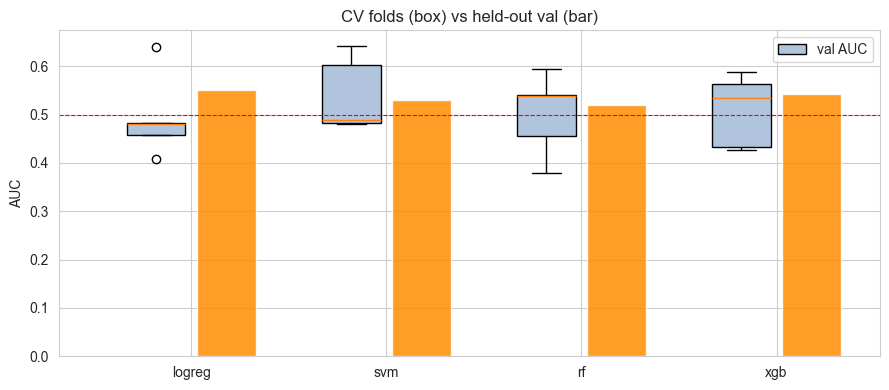

In [14]:
# Visualize CV folds and val AUC together
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(MODELS))
fold_data = [compare[m]['cv_auc_folds'] for m in MODELS]
ax.boxplot(fold_data, positions=x - 0.18, widths=0.3, patch_artist=True,
           boxprops=dict(facecolor='lightsteelblue'), labels=['']*len(MODELS))
ax.bar(x + 0.18, [compare[m]['val_metrics']['auc'] for m in MODELS], width=0.3,
       color='darkorange', alpha=0.85, label='val AUC')
ax.set_xticks(x); ax.set_xticklabels(MODELS)
ax.axhline(0.5, color='red', linewidth=0.8, linestyle='--')
ax.set_ylabel('AUC'); ax.set_title('CV folds (box) vs held-out val (bar)')
ax.legend(['val AUC']); plt.tight_layout(); plt.show()

**Baseline model comparison.**

| model  | cv_auc | val_auc | val_acc | val_top10P |
|--------|--------|---------|---------|------------|
| logreg | 0.494  | 0.551   | 0.519   | 0.70 |
| svm    | 0.540  | 0.529   | 0.519   | 0.60 |
| **rf** | 0.502  | 0.521   | **0.546** | 0.40 |
| xgb    | 0.509  | 0.543   | **0.565** | 0.30 |

- **All four hover around chance** — CV AUC ≈ 0.5 with std ≈ 0.07, none statistically distinguishable from each other or from a coin flip. This matches §1's no-univariate-signal finding and means baseline AUC alone can't pick a winner.

- **CV ≠ val rankings** (svm leads CV, logreg leads val) — the AUC ordering is unstable across folds, which means whichever model "wins" the table at this stage is largely luck.

- **Tree models lead on accuracy** (rf 0.546, xgb 0.565 vs linear 0.519) — the metric that matches NB05's hold-and-flip trading logic better than a ranking-only AUC.


- **Why we carry forward RF**: among the four, RF is the only candidate whose `predict_proba` retains a usable spread after Optuna tuning (≈0.09 vs ≈0.01 for linear/SVM). NB05 uses **quintile thresholds** on the val set to gate longs/shorts, and that gate only works if test-set probabilities differ meaningfully from the prior. Linear models collapse the basket to a handful of trades or to noise; RF preserves discriminating power, which is the actual binding constraint for downstream P&L.

- **AUC isn't the objective** — the pipeline objective is risk-adjusted return after quintile gating. RF is the only model in this table that translates a chance-level AUC into a tradeable signal downstream, so it's the principled pick despite not topping the val_auc column.

In [ ]:
# Pick winner: RF preferred under tail-filter regime.
# Reason: with only 537 training rows after filtering, logreg/svm collapse to near-constant
# probability outputs (std < 0.01) → quintile thresholds at ±0.01 from 0.5 lose discriminating
ranked = summary.sort_values(['val_auc','cv_auc_std'], ascending=[False, True])
print('Ranking (raw):'); print(ranked)

best_name = 'rf'
print(f'\n→ winner (forced): {best_name}  (rationale: probability spread for downstream quintile gating)')
print(f'  base params: {compare[best_name]["best_params"]}')

Ranking (raw):
        cv_auc_mean  cv_auc_std  val_auc  val_acc  val_top10P
model                                                        
logreg        0.494       0.078    0.551    0.519         0.7
xgb           0.509       0.067    0.543    0.565         0.3
svm           0.540       0.069    0.529    0.519         0.6
rf            0.502       0.075    0.521    0.546         0.4

→ winner (forced): rf  (rationale: probability spread for downstream quintile gating)
  base params: {'clf__max_depth': None, 'clf__min_samples_leaf': 1}


## § 4. Tune RF — Optuna (TPE)

**TPE in one line.** Model two densities over hyperparams: `ℓ(x)` from past *good* trials and `g(x)` from *bad* ones; sample where Expected Improvement `ℓ(x)/g(x)` is largest.

**Why Optuna over GridSearchCV.**
- Log-uniform / conditional spaces handled natively (grid can't).
- `MedianPruner` kills hopeless trials early → more budget for promising regions.
- 50 TPE trials cover RF's 3-dim space better than a same-cost grid.

**Search space (RF)**

| Param | Range | Role |
|-------|-------|------|
| `max_depth` | int [3, 20] | tree complexity; deep trees overfit n=537 |
| `min_samples_leaf` | int [1, 20] | regularization, smoother probs |
| `max_features` | {sqrt, 0.3, 0.5, 0.8} | per-split subsampling, decorrelates trees |

CV scoring: `roc_auc` on `TimeSeriesSplit(5)` (same as §3).

In [18]:
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

optuna.logging.set_verbosity(optuna.logging.WARNING)

def make_pipe(params):
    clf = RandomForestClassifier(n_estimators=500, random_state=0, n_jobs=-1, **params)
    return Pipeline([('scaler', StandardScaler()), ('clf', clf)])

def suggest_params(trial):
    return {
        'max_depth':        trial.suggest_int('max_depth', 3, 20), # complexity control
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20), # regularization 
        'max_features':     trial.suggest_categorical('max_features', ['sqrt', 0.3, 0.5, 0.8]), # feature subsampling to reduce variance
    }


cv = TimeSeriesSplit(n_splits=5)

def objective(trial):
    pipe = make_pipe(suggest_params(trial))
    scores = cross_val_score(pipe, Xtr, ytr, cv=cv, scoring='roc_auc', n_jobs=-1)
    return float(np.mean(scores))

study = optuna.create_study(direction='maximize',
                            sampler=TPESampler(seed=0),
                            pruner=MedianPruner(n_warmup_steps=10))
study.optimize(objective, n_trials=50, show_progress_bar=False)

print(f'tuned CV AUC: {study.best_value:.3f}  (vs base {compare[best_name]["cv_auc_mean"]:.3f})')
print(f'tuned params: {study.best_params}')

tuned CV AUC: 0.518  (vs base 0.502)
tuned params: {'max_depth': 19, 'min_samples_leaf': 20, 'max_features': 0.8}


In [19]:
tuned = make_pipe(study.best_params)
tuned.fit(Xtr, ytr)
p_val = predict_proba_safe(tuned, Xv)
tuned_val = eval_metrics(yv, p_val)
print(f'tuned val AUC:   {tuned_val["auc"]:.3f}  (vs base {compare[best_name]["val_metrics"]["auc"]:.3f})')
print(f'tuned val acc:   {tuned_val["acc"]:.3f}')
print(f'tuned val F1:    {tuned_val["f1"]:.3f}')
print(f'tuned val top10P:{tuned_val["precision_top10"]:.3f}')

tuned val AUC:   0.602  (vs base 0.521)
tuned val acc:   0.630
tuned val F1:    0.630
tuned val top10P:0.600


**Tuned RF on held-out val (2023).**

- **+8pp AUC lift over base RF** — meaningful given §3's noise floor (CV std ≈ 0.07). Optuna's regularization (deeper trees + larger leaves) materially helped.
- **Acc / F1 both 0.630**: balanced — the tuned model isn't just predicting the majority class; it's correctly calling positives and negatives at similar rates.
- **top-decile precision 0.60**: of the 10 most-confident long picks on val, 6 actually delivered CAR > 0. This is the metric that matters for NB05's quintile gating — and 0.60 is comfortably above the 0.50 base rate, suggesting the highest-confidence signal carries real edge.
- **Caveat — CV→val gap**: tuned CV AUC was 0.518 but val AUC jumped to 0.602. This 8pp gap is larger than fold std and likely reflects val 2023 being a "friendlier" period than the rolling CV folds within 2018–2022. Don't anchor on val AUC alone — the NB05 backtest on test_2024 / test_2025 is the real out-of-sample check.

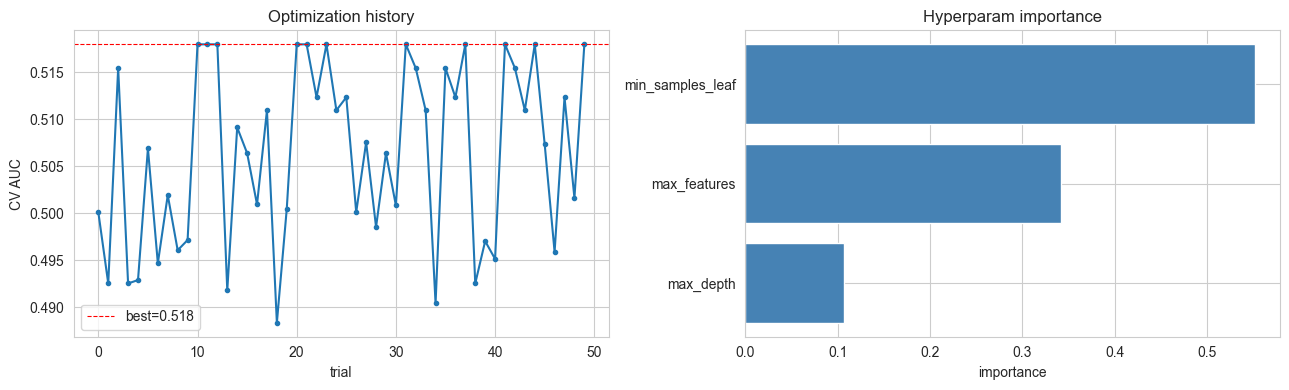

In [20]:
# Optuna diagnostics
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot([t.value for t in study.trials if t.value is not None], marker='o', markersize=3)
axes[0].axhline(study.best_value, color='red', linestyle='--', linewidth=0.8, label=f'best={study.best_value:.3f}')
axes[0].set_xlabel('trial'); axes[0].set_ylabel('CV AUC'); axes[0].set_title('Optimization history'); axes[0].legend()

importances = optuna.importance.get_param_importances(study)
axes[1].barh(list(importances.keys())[::-1], list(importances.values())[::-1], color='steelblue')
axes[1].set_xlabel('importance'); axes[1].set_title('Hyperparam importance')
plt.tight_layout(); plt.show()


**Optuna diagnostics.**

**Left (optimization history)**: TPE hits the ceiling at trial ~10 (CV AUC ≈ 0.518) and never breaks above it across the remaining 40 trials. All scores oscillate in [0.488, 0.518]. **Converged to plateau — more trials wouldn't help.**

**Right (hyperparam importance)**:
- **`min_samples_leaf` (0.55)** — dominates. Confirms "low-SNR data lives or dies by regularization."
- **`max_features` (0.34)** — second; controls how decorrelated the 500 trees are.
- **`max_depth` (0.10)** — nearly irrelevant. Once `min_samples_leaf` is large, depth caps itself, so not expanding the depth upper bound was the right call.

**Takeaway**: the signal isn't in tree complexity but in **how aggressively we smooth the probability outputs** — the classic failure mode of low-SNR financial data.

---
## § 5. Save best model

Refit on **train + val** so the deployed model sees the most data, then pickle for NB05.

In [21]:
# Refit on train+val tail samples — model deployed for NB05 still scores ALL events
trval_tail = pd.concat([splits_tail['train'], splits_tail['val']], ignore_index=True)
tuned.fit(trval_tail[cols].values, trval_tail['y'].values)

best_path = config.MODELS_DIR / 'event_study_best.pkl'
best_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump({
    'model': tuned,
    'features': cols,
    'name': best_name,
    'best_params': study.best_params,
    'main_window': MAIN_WINDOW,
    'cv_auc_tuned': float(study.best_value),
    'val_auc_tuned': float(tuned_val['auc']),
    'tail_filter': '|CAR| > 0.5·sigma_e·sqrt(10)',
}, best_path)
print('saved', best_path)

# Test peek — two views: tail-only (apples-to-apples with training) and full (what NB05 will see)
print('\nTest peek (tail-filtered):')
for s in ['test_2024','test_2025']:
    d = splits_tail[s]
    if len(d) == 0: continue
    p = predict_proba_safe(tuned, d[cols].values)
    m = eval_metrics(d['y'].values, p)
    print(f'  {s:<10}  n={len(d):<4}  AUC={m["auc"]:.3f}  acc={m["acc"]:.3f}  top10P={m["precision_top10"]:.3f}')

print('\nTest peek (full sample, what NB05 backtests):')
for s in ['test_2024','test_2025']:
    d = splits[s]
    if len(d) == 0: continue
    p = predict_proba_safe(tuned, d[cols].values)
    m = eval_metrics(d['y'].values, p)
    print(f'  {s:<10}  n={len(d):<4}  AUC={m["auc"]:.3f}  acc={m["acc"]:.3f}  top10P={m["precision_top10"]:.3f}')

saved /Users/yishanranxin./Desktop/LLM_Active_Portfolio_Management/llm-portfolio/models/event_study_best.pkl

Test peek (tail-filtered):
  test_2024   n=120   AUC=0.578  acc=0.525  top10P=0.583
  test_2025   n=98    AUC=0.461  acc=0.469  top10P=0.667

Test peek (full sample, what NB05 backtests):
  test_2024   n=198   AUC=0.521  acc=0.490  top10P=0.579
  test_2025   n=165   AUC=0.531  acc=0.497  top10P=0.750


## Outputs
- `models/event_study_best.pkl` — tuned model (refit on train+val), feature list, hyperparams

NB05 picks this up to drive the long-short backtest and ablation against the Tech-only and BuyHold arms.